In [34]:
import subprocess
import sys

# Activate venv
venv_path = "/ceph/home/student.aau.dk/lj02sb/Subtask2-Alexandros/inference/.venv/bin/activate_this.py"
exec(open(venv_path).read(), {'__file__': venv_path})


 # Subtask 3 Model-Prompt Heatmap

 This notebook visualizes the scores for each prompt on each model in Subtask 3 using a heatmap.

In [35]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


In [36]:
# Define the results directory
RESULTS_DIR = Path('../results/')


In [37]:
def load_scores(results_dir):

    data = []

    for file_path in results_dir.rglob("*.json"):

        # skip files inside the "saved" folder
        if "saved" in file_path.parts:
            continue

        try:
            with open(file_path) as f:
                metrics = json.load(f)

            filename = file_path.stem

            if "_prompt_" not in filename:
                continue

            model_name, prompt_part = filename.rsplit("_prompt_", 1)

            # if json is list
            if isinstance(metrics, list):
                metrics = metrics[0]

            # only keep evaluation files
            if "overall_score" not in metrics:
                continue

            metrics["model"] = model_name
            metrics["prompt_id"] = int(prompt_part)

            data.append(metrics)

        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    return pd.DataFrame(data)

In [38]:
df = load_scores(RESULTS_DIR)

print(df.head())
print(df.columns)
print("Rows:", len(df))


   strict_macro_precision  strict_macro_recall  strict_macro_f1  \
0               42.457071            42.084416        38.685219   
1               44.270512            81.100649        53.238160   
2               23.750000            13.547619        15.921717   
3                6.500000             5.833333         5.694444   
4               29.442308            31.722222        25.659091   

   strict_micro_precision  strict_micro_recall  strict_micro_f1  \
0               53.982301            50.413223        52.136752   
1               34.385965            80.991736        48.275862   
2               66.666667            11.570248        19.718310   
3               35.714286             4.132231         7.407407   
4               37.037037            24.793388        29.702970   

   lenient_macro_precision  lenient_macro_recall  lenient_macro_f1  \
0                45.808442             42.084416         40.330290   
1                49.085257             81.100649      

In [39]:
pivot_df = df.pivot_table(
    index="model",
    columns="prompt_id",
    values="overall_score",
    aggfunc="mean"
)

pivot_df = pivot_df.sort_index(axis=1)

print(pivot_df.head())

prompt_id                            0          1          2          3  \
model                                                                     
BioMistral-BioMistral-7B      0.000000   0.000000   8.163265   0.000000   
Qwen-Qwen3-32B               19.718310  14.598540  17.687075   0.000000   
Qwen-Qwen3-8B                 3.149606   6.201550   0.000000   0.000000   
anthropic-claude-sonnet-4-5  58.730159  57.843137  57.480315   0.000000   
google-gemini-2-5-flash      52.136752  50.965251  48.275862  50.581395   

prompt_id                            4          5          6          7  \
model                                                                     
BioMistral-BioMistral-7B      0.000000   0.000000   0.000000   0.000000   
Qwen-Qwen3-32B                7.407407   8.888889  16.176471   6.250000   
Qwen-Qwen3-8B                 3.149606   4.724409   1.600000   3.100775   
anthropic-claude-sonnet-4-5   0.000000        NaN  55.361596  56.744186   
google-gemini-2-5-flash 

In [40]:
pivot_df["Average"] = pivot_df.mean(axis=1)
pivot_df.loc["Average"] = pivot_df.mean(axis=0)


In [41]:
all_models_existing = list(pivot_df.index)

closed_models = [
    "anthropic-claude-sonnet-4-5",
    "google-gemini-3-flash-preview",
    "google-gemini-2-5-flash",
    "x-ai-grok-4-1-fast"
]

open_models = [
    "meta-llama-Llama-3-1-8B-Instruct",
    "khazarai-Bio-8B-it",
    "Qwen-Qwen3-32B",
    "Qwen-Qwen3-8B",
    "BioMistral-BioMistral-7B"
]

# keep only models that actually exist
closed_models = [m for m in closed_models if m in pivot_df.index]
open_models = [m for m in open_models if m in pivot_df.index]

pivot_df = pivot_df.reindex(closed_models + open_models + ["Average"])


In [42]:
def get_avg(model):
    return pivot_df.loc[model, "Average"]

closed_sorted = sorted(closed_models, key=get_avg, reverse=True)
open_sorted = sorted(open_models, key=get_avg, reverse=True)

all_models = closed_sorted + open_sorted + ["Average"]

pivot_df = pivot_df.reindex(all_models)


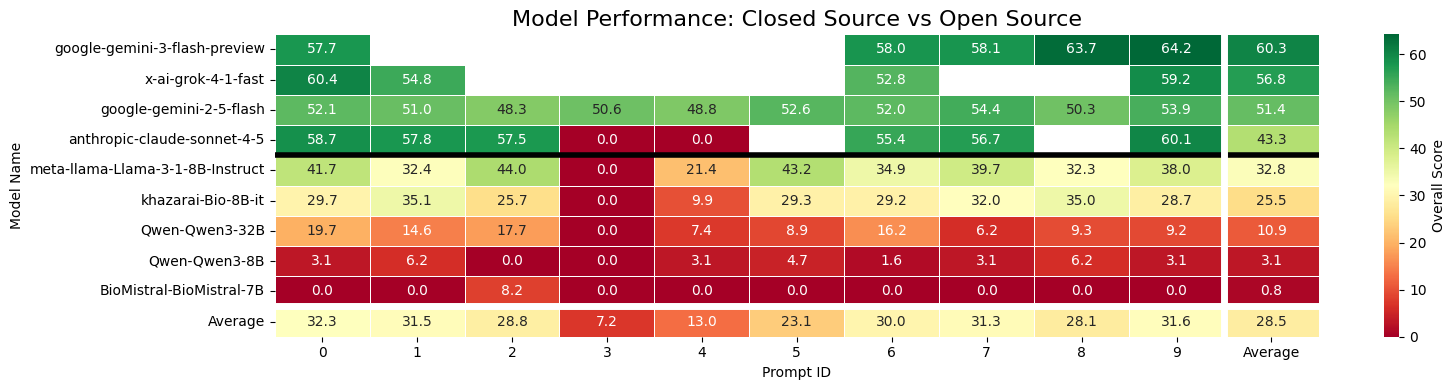

In [43]:
plt.figure(figsize=(16, 4))

ax = sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.5,
    cbar_kws={'label': 'Overall Score'}
)

sep_idx = len(closed_sorted)

ax.axhline(y=sep_idx, color='black', linewidth=4)

ax.axvline(x=pivot_df.shape[1]-1, color='white', linewidth=5)

ax.axhline(y=pivot_df.shape[0]-1, color='white', linewidth=5)

plt.title("Model Performance: Closed Source vs Open Source", fontsize=16)
plt.ylabel("Model Name")
plt.xlabel("Prompt ID")

plt.tight_layout()
plt.show()


In [44]:
print(sorted(df["model"].unique()))

['BioMistral-BioMistral-7B', 'Qwen-Qwen3-32B', 'Qwen-Qwen3-8B', 'anthropic-claude-sonnet-4-5', 'google-gemini-2-5-flash', 'google-gemini-3-flash-preview', 'google-gemini-3-pro-preview', 'khazarai-Bio-8B-it', 'meta-llama-Llama-3-1-8B-Instruct', 'x-ai-grok-4-1-fast']
